## DBSCAN

#### Density-based Spatial Clustering of Applications with Noise is an unsupervised learning algorithm for clustering. There are three particular terms that we need to focus on: density, clustering, and noise.
#### Clusters are created by a process of gathering at least a given number of instances that fall within a set distance from a given datapoint and expanding the territory of these similar datapoints.

### Necessity of Density based Clustering

##### Conventional clustering methods (K-means, PAM clustering and hierarchical clustering) work for finding spherical-shaped clusters or convex clusters. In other words, they are suitable only for compact and well-separated clusters. Moreover, they are severely affected by the presence of noise and outliers in the data.

![download](download.png) 

### Real-life data may contain irregularities:
- Cluster can be arbitrary in shape
- Data is likely to contain noise

![DBscan1](DBscan1.png) 

#### After Applying the DB Scan

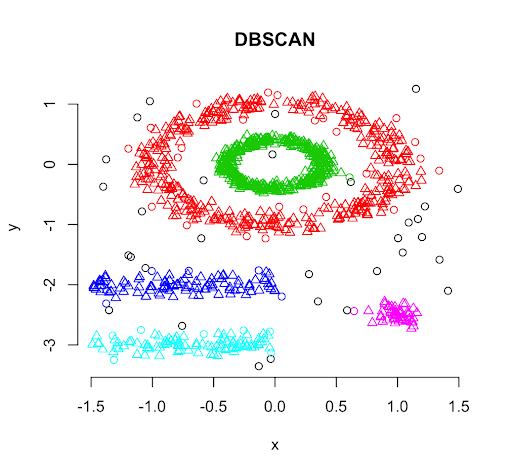

##### The figure above shows a data set containing non-convex shape clusters and outliers. Given such data, the k-means algorithm has difficulties in identifying these clusters with arbitrary shapes.

### Parameters and their Selection

#### epsilon
- It defines the neighborhood around a data point i.e. if the distance between two points is lower or equal to ‘eps’ then they are considered neighbors.


#### MinPts
- Minimum number of neighbors (data points) within eps radius. The larger the dataset, the larger value of MinPts must be chosen.


DBSCAN is very sensitive to the values of epsilon and minPoints. Therefore, it is very important to understand how to select the values of epsilon and minPoints. A slight variation in these values can significantly change the results produced by the DBSCAN algorithm.

The value of minPoints should be at least one greater than the number of dimensions of the dataset, i.e.,

#### minPoints>=Dimensions+1.

It does not make sense to take minPoints as 1 because it will result in each point being a separate cluster. Therefore, it must be at least 3. Generally, it is twice the dimensions. But domain knowledge also decides its value.

#### Value of epsilon
The value of epsilon can be decided from the K-distance graph. The point of maximum curvature (elbow) in this graph tells us about the value of epsilon. If the value of epsilon chosen is too small then a higher number of clusters will be created, and more data points will be taken as noise. Whereas, if chosen too big then various small clusters will merge into a big cluster, and we will lose details.

## In this algorithm, we have 3 types of data points.

### Core Point
- A point is a core point if it has more than MinPts points within eps.
### Border Point
- A point which has fewer than MinPts within eps but it is in the neighborhood of a core point.
### Noise or outlier
- A point which is not a core point or border point.

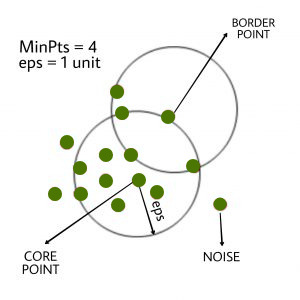

For locating data points in space, DBSCAN uses Euclidean distance, although other methods can also be used (like great circle distance for geographical data). It also needs to scan through the entire dataset once

### Understanding Reachability & Connectivity of Points
* __Reachability__ states if a data point can be accessed from another data point directly or indirectly.
* __Connectivity__ states whether two data points belong to the same cluster or not.


__Directly Density-Reachable__

A point X is directly density-reachable from point Y w.r.t epsilon, minPoints if,

* X belongs to the neighborhood of Y, i.e, dist(X, Y) <= epsilon
* Y is a core point

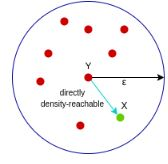int

__Density-Reachable__

* A point X is density-reachable from point Y w.r.t epsilon, minPoints if there is a chain of points p1, p2, p3, …, pn and p1=X and pn=Y such that pi+1 is directly density-reachable from pi.
* X is density-reachable from Y with X being directly density-reachable from P2, P2 from P3, and P3 from Y. But, the inverse of this is not valid.

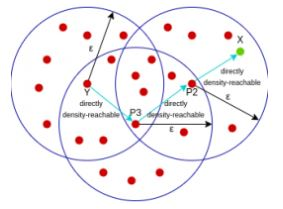

__Density-Connected__
* A point X is density-connected from point Y w.r.t epsilon and minPoints if there exists a point O such that both X and Y are density-reachable from O w.r.t to epsilon and minPoints.
* Here, both X and Y are density-reachable from O, therefore, we can say that X is density-connected from Y.

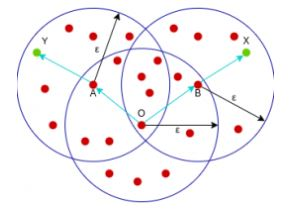

### Working of DB Scan

<video controls style="width: 50%;" src="videoplayback.mp4" />


### DBSCAN advantages over other clustering algorithms:
#### Cluster shape: DBSCAN can identify clusters of varying shapes, while other algorithms like KMeans can only create globular clusters.
#### Cluster size: DBSCAN can find clusters of arbitrary shapes and sizes.
#### Number of clusters: DBSCAN doesn't require the user to specify the number of clusters in the data beforehand.
#### Outliers: DBSCAN is robust to noise and outliers, since they are not assigned to any cluster.
#### Notion of noise: DBSCAN has a notion of noise, and is robust to outliers. 


## Implementation 
#### Clustering Penguins based on their physicality and gender

In [1]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv("penguins.csv")

In [3]:
data

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...
339,NaN,NaN,NaN,NaN,NaN
340,46.8,14.3,215.0,4850.0,FEMALE
341,50.4,15.7,222.0,5750.0,MALE
342,45.2,14.8,212.0,5200.0,FEMALE


In [6]:
data.isna().sum()

culmen_length_mm     2
culmen_depth_mm      2
flipper_length_mm    2
body_mass_g          2
sex                  9
dtype: int64

In [4]:
data=data.dropna()

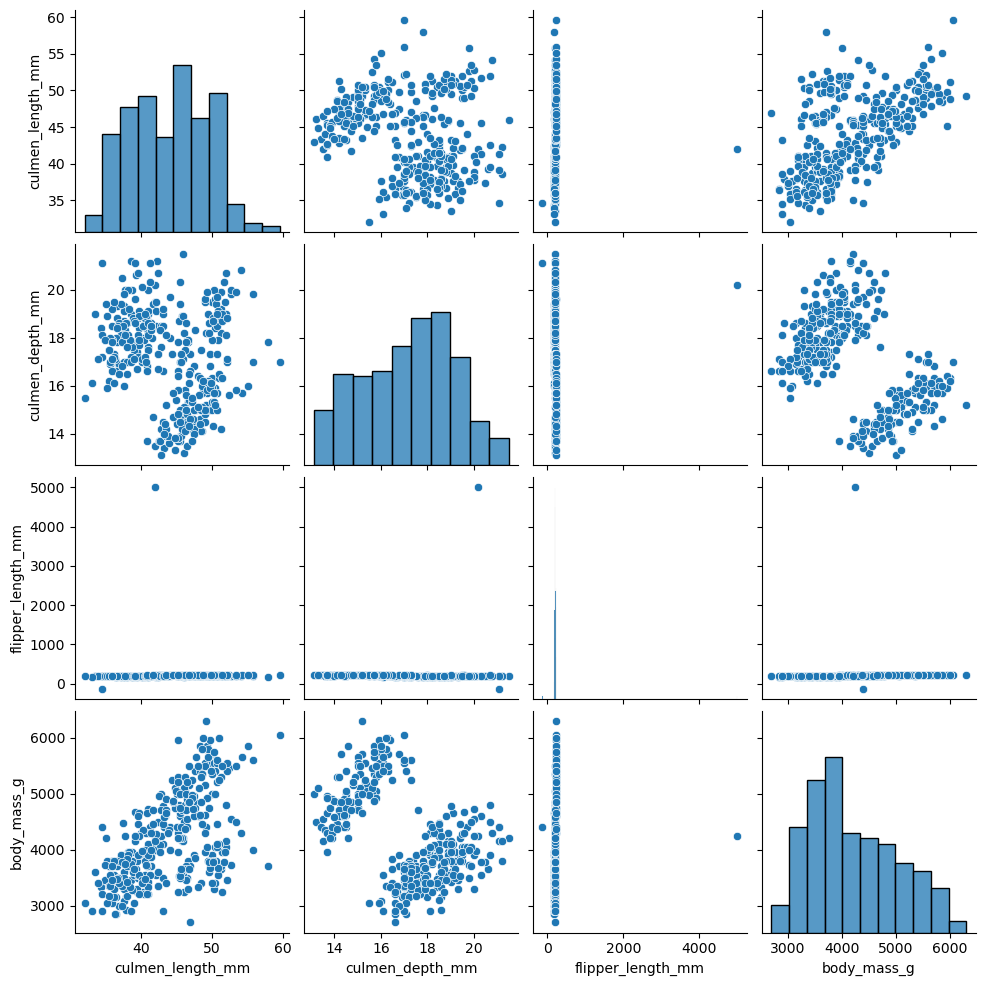

In [8]:
import seaborn as sns
sns.pairplot(data)
plt.show()

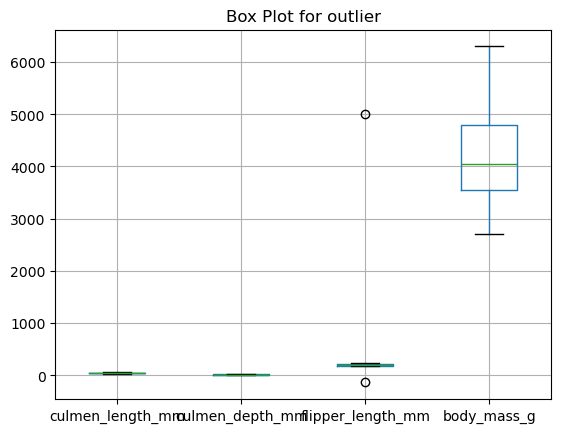

In [9]:
data.boxplot()

# Add a title to the plot
plt.title('Box Plot for outlier')

# Show the plot
plt.show()

In [10]:
data[data["flipper_length_mm"] > 4000]

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
9,42.0,20.2,5000.0,4250.0,MALE


In [11]:
data[data["flipper_length_mm"] < 0]

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
14,34.6,21.1,-132.0,4400.0,MALE


In [5]:
data=data.drop([9, 14])

In [6]:
df_encoded = pd.get_dummies(data, columns=['sex'], dtype=int)

In [7]:
df_encoded.drop('sex_.',axis=1,inplace=True)

In [8]:
data=df_encoded

## Scaling the data

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(data)
penguins_preprocessed = pd.DataFrame(data=X, columns=data.columns)
penguins_preprocessed.head(10)

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex_FEMALE,sex_MALE
0,-0.905520,0.793126,-1.428125,-0.569709,-0.991031,0.997001
1,-0.831938,0.128503,-1.071522,-0.507579,1.009050,-1.003008
2,-0.684775,0.435252,-0.429637,-1.191006,1.009050,-1.003008
3,-1.347011,1.099875,-0.572278,-0.942487,1.009050,-1.003008
4,-0.868729,1.764498,-0.786240,-0.693968,-0.991031,0.997001
5,-0.942311,0.333002,-1.428125,-0.725033,1.009050,-1.003008
6,-0.887125,1.253249,-0.429637,0.579691,-0.991031,0.997001
7,-0.537611,0.230753,-1.356804,-1.253136,1.009050,-1.003008
8,-0.997497,2.071247,-0.714919,-0.507579,-0.991031,0.997001
9,-1.365406,0.333002,-1.142843,-0.631839,1.009050,-1.003008


### Plotting K Nearest graph

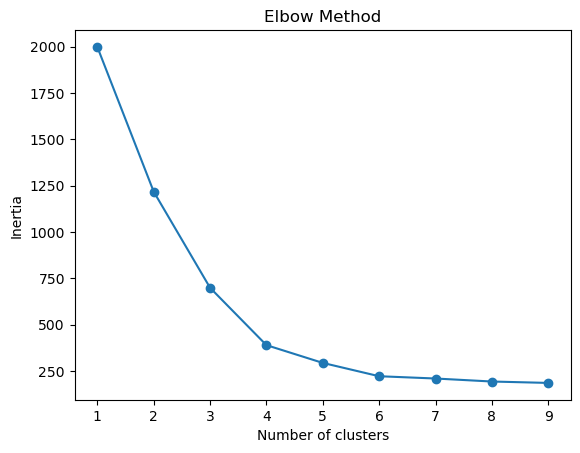

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(penguins_preprocessed)
    inertia.append(kmeans.inertia_)
plt.plot(range(1, 10), inertia, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


### Plotting the K-distance Graph

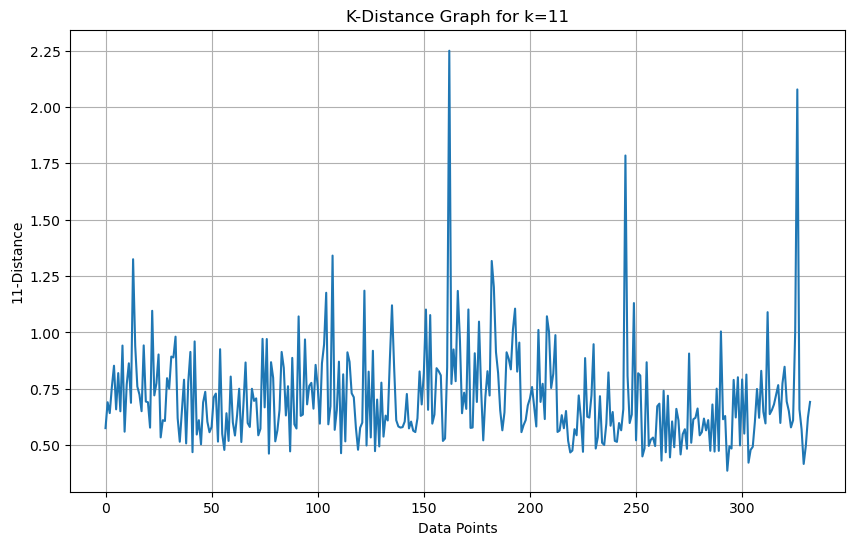

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances

def plot_k_distance(data, k):
    # Calculate pairwise distances between all points
    distances = pairwise_distances(penguins_preprocessed)
    
    # Sort the distances for each point
    sorted_distances = np.sort(distances, axis=1)
    
    # Select the k-th smallest distance as the k-distance for each point
    k_distances = sorted_distances[:, k - 1]
    
    # Plot the k-distance graph
    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(len(data)), k_distances)
    plt.xlabel('Data Points')
    plt.ylabel(f'{k}-Distance')
    plt.title(f'K-Distance Graph for k={k}')
    plt.grid(True)
    plt.show()

# Example usage:
# data is your dataset, k is the parameter for k-distance
plot_k_distance(data, 11)


In [24]:
def get_kdist_plot(X=None, k=None, radius_nbrs=1.0):

    nbrs = NearestNeighbors(n_neighbors=k, radius=radius_nbrs).fit(X)

    # For each point, compute distances to its k-nearest neighbors
    distances, indices = nbrs.kneighbors(X) 
                                       
    distances = np.sort(distances, axis=0)
    distances = distances[:, k-1]

    # Plot the sorted K-nearest neighbor distance for each point in the dataset
    plt.figure(figsize=(8,8))
    plt.plot(distances)
    plt.xlabel('Points/Objects in the dataset', fontsize=12)
    plt.ylabel('Sorted {}-nearest neighbor distance'.format(k), fontsize=12)
    plt.grid(True, linestyle="--", color='black', alpha=0.4)
    plt.show()
    plt.close()
    

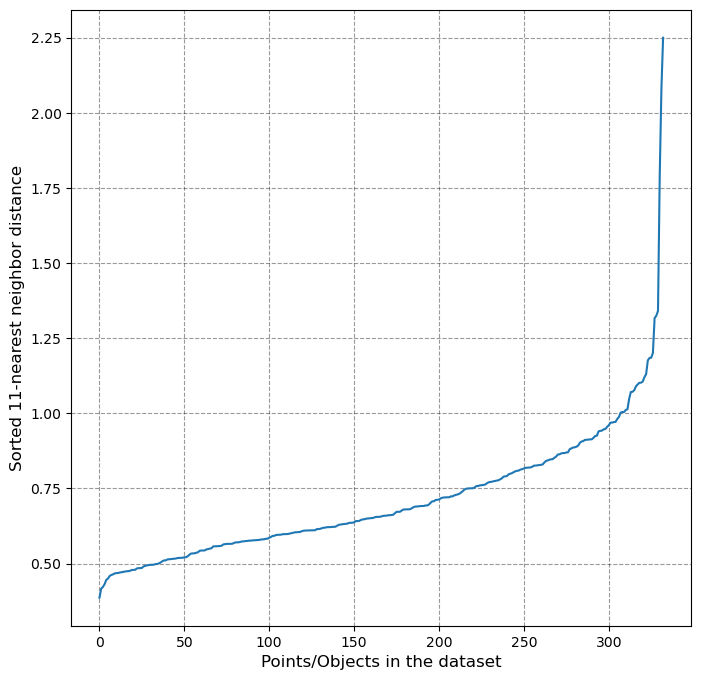

In [25]:
from sklearn.neighbors import NearestNeighbors
k = 2 * penguins_preprocessed.shape[-1] - 1 # k=2*{dim(dataset)} - 1
get_kdist_plot(X=penguins_preprocessed, k=k)


# Model Creation

In [26]:
from sklearn.cluster import DBSCAN
epsilon =1.0  # Specify the maximum distance between two samples to be considered as neighbors
min_samples = 11  # Specify the number of samples in a neighborhood for a point to be considered as a core point
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)

# Fit DBSCAN to the data and predict cluster labels
cluster_labels = dbscan.fit_predict(penguins_preprocessed)

# Display the cluster labels
print("Cluster labels:", cluster_labels)

Cluster labels: [ 0  1  1  1  0  1  0  1  0  1  1  0  1  0  1  0  1  0  0  1  0  1  1  0
  1  0  1  0  1  0  0  1  1  0  1  0  1  0  1  0  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  0  1  0  1  1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0 -1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  0  1  1  0  1
  0  1  0  0  1  0  1  1  0  1  0  1  0  1  0  1  0  0 -1  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  0  1  1  0  1  0  0  1  0  1  1  0  1
  0  0  1  1  0  1  0  1  0  1  0  0  1  0  1  1  0  1  0  0  1  2  3  2
  3  3  2  2  3  2  3  2  3  2  3  2  3  2  3  2  3  3  2  2  3  2  3  3
  2  3  3  2  2 -1  2  3  2  3  2  3  2  3  2  3  3  2  2  3  2  3  2  3
  2  3  2  3  2  3  2  3  2  3  2  3  2  3  3  2  3  2  3  3  2  2  3  2
  3  2  3  2  3  2  3  2  3  2  3  2  3  2  3  2  3  2  3  3  2  2  3  2
  3  2  3  3  2  3  2  3  2  3  2  

__fit(X[, y, sample_weight])__ : Perform DBSCAN clustering from features, or distance matrix.

__fit_predict(X[, y, sample_weight])__ : Compute clusters from a data or distance matrix and predict labels.

## Visualizing the formed clusters

For Easy understanding the formed cluster , we plot the graphs in different dimension , for same clusters formed.

In [22]:
X=penguins_preprocessed

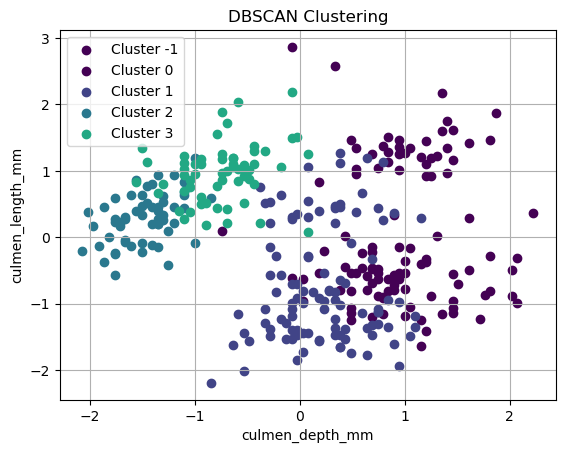

In [27]:
import matplotlib.pyplot as plt


unique_labels = np.unique(cluster_labels)

# Define a color scheme for clusters (adjust as needed)
color_scheme = plt.cm.get_cmap('viridis')  # Or any other colormap

for cluster_label in unique_labels:
  # Select data points belonging to the current cluster
  cluster_data = penguins_preprocessed[cluster_labels == cluster_label]

  # Access the desired columns directly
  plt.scatter(cluster_data['culmen_depth_mm'], cluster_data['culmen_length_mm'], color=color_scheme((cluster_label) / len(unique_labels)), label=f'Cluster {cluster_label}')

plt.title('DBSCAN Clustering')
plt.xlabel('culmen_depth_mm')  # Adjust axis labels if needed
plt.ylabel('culmen_length_mm')
plt.legend()
plt.grid(True)
plt.show()


### for Better visibility of cluster, we have plotted the features in 3D, for rotation and adjustment of the plot , can change the values for elev, azim

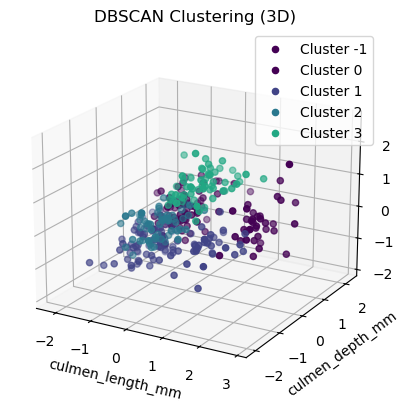

In [28]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

unique_labels = np.unique(cluster_labels)

# Define a color scheme for clusters (adjust as needed)
color_scheme = plt.cm.get_cmap('viridis')  # Or any other colormap

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for cluster_label in unique_labels:
  # Select data points belonging to the current cluster
  cluster_data = penguins_preprocessed[cluster_labels == cluster_label]

  # Access the desired columns directly
  ax.scatter(cluster_data['culmen_length_mm'], cluster_data['culmen_depth_mm'], cluster_data['body_mass_g'],
             color=color_scheme((cluster_label) / len(unique_labels)), label=f'Cluster {cluster_label}')

# Adjust axis labels
ax.set_xlabel('culmen_length_mm')
ax.set_ylabel('culmen_depth_mm')
ax.set_zlabel('body_mass_g')

ax.set_title('DBSCAN Clustering (3D)')
ax.legend()
ax.view_init(elev=20, azim=-60)  # 15 degrees elevation, -60 degrees azimuth

plt.show()


## Evaluation

In [29]:
from sklearn.metrics import silhouette_score
# Evaluate clustering with silhouette score
silhouette_avg = silhouette_score(penguins_preprocessed, cluster_labels)
print("Silhouette Score:", silhouette_avg)



Silhouette Score: 0.5663944251071912


### We are able to achive a Silhouette score of 0.56.
The hyperparameters Epsilon and MinPts can be varied as per requirement. There can be combinations of these parameters that deliver a more optimal clustering.